In [3]:
#Name: Anisa
#section: G
#cms-id: 023-23-0222
#http://kaggle.com/datasets/abbas829/telco-customer-churn-dataset




In [4]:
#Task1
import pandas as pd
import numpy as np

df = pd.read_csv("clean_churn.csv")
print(df.shape)     
print(df.info())   

(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

In [5]:
#Task2
'''
As we have seen in lab3 descision tree test result there was 74.2 accuracy, 51.4 precision, 49.5 recall and 50.4 f1-score.
In lab4 random forest test result there was 78.6% accuracy, 62.4% precision, 49.2% recall and  55.0% F1-score which was better in accuracy and precision as compare to decision tree but their recall was almost equivalent that was their common weak point which will be compared with new models of today.
'''

'\nAs we have seen in lab3 descision tree test result there was 74.2 accuracy, 51.4 precision, 49.5 recall and 50.4 f1-score.\nIn lab4 random forest test result there was 78.6% accuracy, 62.4% precision, 49.2% recall and  55.0% F1-score which was better in accuracy and precision as compare to decision tree but their recall was almost equivalent that was their common weak point which will be compared with new models of today.\n'

In [6]:
# Task 3
categorical_cols = df.select_dtypes(include="object").columns.tolist()
if "Churn" in categorical_cols:
    categorical_cols.remove("Churn")

print(categorical_cols)   # yeh check karne ke liye ke list sahi bani

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
X = df_encoded.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0}) if df["Churn"].dtype == "object" else df["Churn"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Task 5(part A): scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_scaled = scaler.transform(X_test)          # sirf transform, fit nahi


['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
# Task 5( past B):    
'''
if we use fit(train+test) scaler function to complete dataset then there will be risk of leakage of test information during training process which we call "data leakage". In real world, models are unaware of the test data and its result hence we should provide scaler with just training data and apply the same statistics (mean, std) to test data.
'''

'\nif we use fit(train+test) scaler function to complete dataset then there will be risk of leakage of test information during training process which we call "data leakage". In real world, models are unaware of the test data and its result hence we should provide scaler with just training data and apply the same statistics (mean, std) to test data.\n'

Accuracy: 0.807, Precision: 0.658, Recall: 0.567, F1: 0.609


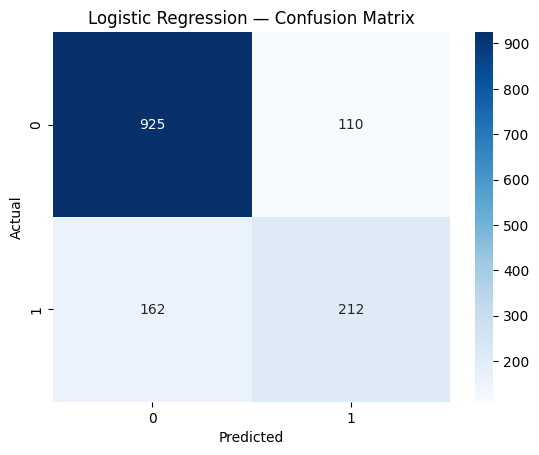

In [8]:
# Task 6-7
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [9]:
# Task 8
probs = logreg.predict_proba(X_test_scaled)[:10]   # [P(No), P(Yes)] pehle 10 customers ke liye
print(probs)
'''
The function predict_proba provide two values for each customer (no, yes) that answers upto 1. lets take an example if customer_id 2 output result[0.316, 0.684] that means according to the model there is 68.4% chances of customer_id 2 to churn. teh function predict() uses 0.5 as threshold, so if p(yes)>0.5 it will be considered 1(means churn) otherwise 0(means no churn). so customer_id 2 will be predicted as churn 
'''

[[0.95563487 0.04436513]
 [0.31639994 0.68360006]
 [0.94356046 0.05643954]
 [0.59169375 0.40830625]
 [0.97830853 0.02169147]
 [0.3956336  0.6043664 ]
 [0.54727943 0.45272057]
 [0.86879334 0.13120666]
 [0.99709179 0.00290821]
 [0.60575155 0.39424845]]


'\nThe function predict_proba provide two values for each customer (no, yes) that answers upto 1. lets take an example if customer_id 2 output result[0.316, 0.684] that means according to the model there is 68.4% chances of customer_id 2 to churn. teh function predict() uses 0.5 as threshold, so if p(yes)>0.5 it will be considered 1(means churn) otherwise 0(means no churn). so customer_id 2 will be predicted as churn \n'

    K  Accuracy        F1
0   1  0.716111  0.476440
1   3  0.743790  0.512821
2   5  0.747339  0.512329
3   7  0.759404  0.532414
4   9  0.770050  0.558583
5  11  0.773598  0.563611
6  15  0.770050  0.554945
7  21  0.770759  0.561737


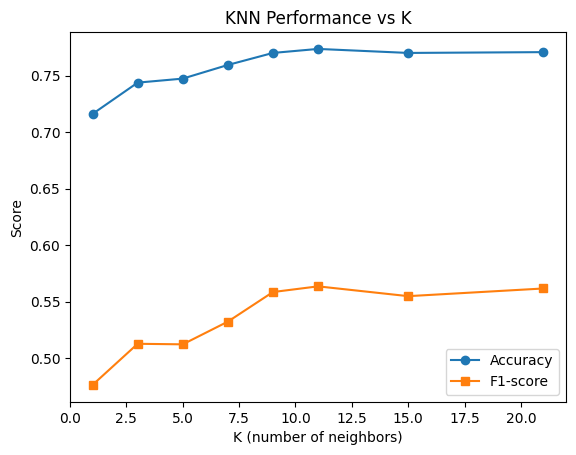

In [10]:
# Task 9-10
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    results.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, y_pred_k),
        "F1": f1_score(y_test, y_pred_k)
    })

results_df = pd.DataFrame(results)
print(results_df)

plt.plot(results_df["K"], results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["K"], results_df["F1"], marker="s", label="F1-score")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Score")
plt.title("KNN Performance vs K")
plt.legend()
plt.show()

Accuracy: 0.7735982966643009
Precision: 0.5770308123249299
Recall: 0.5508021390374331
F1: 0.5636114911080712


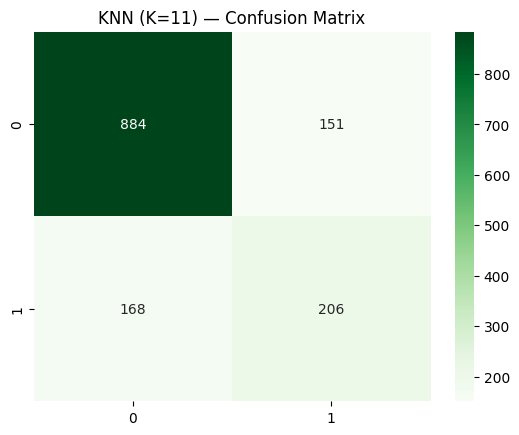

In [11]:
# Task 11
final_k = 11   # apne plot se chosen K yahan dalein
knn_final = KNeighborsClassifier(n_neighbors=final_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens")
plt.title(f"KNN (K={final_k}) — Confusion Matrix")
plt.show()

In [12]:
# To retrain the values of accuracy of models that are evaluated in previous labs.
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Decision Tree (Lab 3 jaisa) ---
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)              # NOTE: scaled nahi, raw X_train — tree ko scaling ki zaroorat nahi
y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# --- Random Forest (Lab 4 jaisa) ---
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("DT:", dt_acc, dt_prec, dt_rec, dt_f1)
print("RF:", rf_acc, rf_prec, rf_rec, rf_f1)
# Task 12
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression", "KNN"],
    "Accuracy": [dt_acc, rf_acc, acc, accuracy_score(y_test, y_pred_knn)],
    "Precision": [dt_prec, rf_prec, prec, precision_score(y_test, y_pred_knn)],
    "Recall": [dt_rec, rf_rec, rec, recall_score(y_test, y_pred_knn)],
    "F1-score": [dt_f1, rf_f1, f1, f1_score(y_test, y_pred_knn)],
})
print(comparison_df)

DT: 0.7416607523066004 0.5138888888888888 0.4946524064171123 0.5040871934604905
RF: 0.7863733144073811 0.6237288135593221 0.4919786096256685 0.5500747384155455
                 Model  Accuracy  Precision    Recall  F1-score
0        Decision Tree  0.741661   0.513889  0.494652  0.504087
1        Random Forest  0.786373   0.623729  0.491979  0.550075
2  Logistic Regression  0.806955   0.658385  0.566845  0.609195
3                  KNN  0.773598   0.577031  0.550802  0.563611


In [13]:
# Task 13
'''
In terms of accuracy, logistic regression is best (80.7%), further Random Forest (78.6%), KNN (77.0%), and at least is Decision Tree (74.2%). In terms of recall there is a little cahnge in ranking: Logistic Regression is still top (56.7%), but now KNN is second (54.8%) — Random Forest drops to third (49.2%), Decision Tree is at the bottom (49.5%, same as Random Forest).
because in lab2 EDA we saw class imbalance (more "No churn" customers), so we cannot rely solely on accuracy — a model that always predicts "No" can also show high accuracy without being actually useful. Therefore, recall (or F1, which balances precision and recall) is a more meaningful metric, as it tells us how many of the actual churners the model is catching. From this lens too, Logistic Regression is ahead — consistently best in both metrics, hence changing the ranking metric does not change the outcome.

'''

'\nIn terms of accuracy, logistic regression is best (80.7%), further Random Forest (78.6%), KNN (77.0%), and at least is Decision Tree (74.2%). In terms of recall there is a little cahnge in ranking: Logistic Regression is still top (56.7%), but now KNN is second (54.8%) — Random Forest drops to third (49.2%), Decision Tree is at the bottom (49.5%, same as Random Forest).\nbecause in lab2 EDA we saw class imbalance (more "No churn" customers), so we cannot rely solely on accuracy — a model that always predicts "No" can also show high accuracy without being actually useful. Therefore, recall (or F1, which balances precision and recall) is a more meaningful metric, as it tells us how many of the actual churners the model is catching. From this lens too, Logistic Regression is ahead — consistently best in both metrics, hence changing the ranking metric does not change the outcome.\n\n'

In [14]:
#Task 14
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg.coef_[0]
})
coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])
coef_df = coef_df.sort_values("Coefficient", ascending=False)
print(coef_df)

                                  Feature  Coefficient  Odds Ratio
10            InternetService_Fiber optic     0.778760    2.178770
3                            TotalCharges     0.497246    1.644187
23                    StreamingMovies_Yes     0.258653    1.295184
21                        StreamingTV_Yes     0.258042    1.294393
9                       MultipleLines_Yes     0.216356    1.241545
26                   PaperlessBilling_Yes     0.181833    1.199414
28         PaymentMethod_Electronic check     0.181456    1.198962
17                   DeviceProtection_Yes     0.053625    1.055089
0                           SeniorCitizen     0.052901    1.054326
29             PaymentMethod_Mailed check     0.033133    1.033687
4                             gender_Male     0.011110    1.011172
5                             Partner_Yes     0.010629    1.010686
7                        PhoneService_Yes     0.007680    1.007710
8          MultipleLines_No phone service    -0.007680    0.99

In [15]:
# Task 15
'''
 According to Task 14's coefficients, the strongest predictors are: InternetService_Fiber optic (positive, increases churn), tenure and Contract_Two year (negative, decreases churn). This aligns quite closely with the Decision Tree feature importances from Lab 3 — tenure and Contract were also top features there, as the tree made splits based on these attributes. In Lab 2's EDA, we also observed a strong visual relationship between Contract type and tenure with churn (month-to-month + low tenure customers had the highest churn rate).

A slight disagreement exists: InternetService_Fiber optic has the strongest positive coefficient here, but it wasn't as high in the Decision Tree's feature importance list. [Likely] This is because Logistic Regression coefficients show an "holding everything else constant" effect, while the tree's split only considers the feature with the best information gain — if MonthlyCharges and InternetService are correlated, the tree might only highlight one of them as "important" while Logistic Regression assigns separate weights to both.
'''

'\n According to Task 14\'s coefficients, the strongest predictors are: InternetService_Fiber optic (positive, increases churn), tenure and Contract_Two year (negative, decreases churn). This aligns quite closely with the Decision Tree feature importances from Lab 3 — tenure and Contract were also top features there, as the tree made splits based on these attributes. In Lab 2\'s EDA, we also observed a strong visual relationship between Contract type and tenure with churn (month-to-month + low tenure customers had the highest churn rate).\n\nA slight disagreement exists: InternetService_Fiber optic has the strongest positive coefficient here, but it wasn\'t as high in the Decision Tree\'s feature importance list. [Likely] This is because Logistic Regression coefficients show an "holding everything else constant" effect, while the tree\'s split only considers the feature with the best information gain — if MonthlyCharges and InternetService are correlated, the tree might only highlight 

In [16]:
# Task 16
'''
According to Task 14's coefficients, the strongest predictors are: InternetService_Fiber optic (positive, increases churn), tenure and Contract_Two year (negative, decreases churn). This aligns quite closely with the Decision Tree feature importances from Lab 3 — tenure and Contract were also top features there, as the tree made splits based on these attributes. In Lab 2's EDA, we also observed a strong visual relationship between Contract type and tenure with churn (month-to-month + low tenure customers had the highest churn rate).

A slight disagreement exists: InternetService_Fiber optic has the strongest positive coefficient here, but it wasn't as high in the Decision Tree's feature importance list. [Likely] This is because Logistic Regression coefficients show an "holding everything else constant" effect, while the tree's split only considers the feature with the best information gain — if MonthlyCharges and InternetService are correlated, the tree might only highlight one of them as "important" while Logistic Regression assigns separate weights to both.
'''

'\nAccording to Task 14\'s coefficients, the strongest predictors are: InternetService_Fiber optic (positive, increases churn), tenure and Contract_Two year (negative, decreases churn). This aligns quite closely with the Decision Tree feature importances from Lab 3 — tenure and Contract were also top features there, as the tree made splits based on these attributes. In Lab 2\'s EDA, we also observed a strong visual relationship between Contract type and tenure with churn (month-to-month + low tenure customers had the highest churn rate).\n\nA slight disagreement exists: InternetService_Fiber optic has the strongest positive coefficient here, but it wasn\'t as high in the Decision Tree\'s feature importance list. [Likely] This is because Logistic Regression coefficients show an "holding everything else constant" effect, while the tree\'s split only considers the feature with the best information gain — if MonthlyCharges and InternetService are correlated, the tree might only highlight o

In [17]:
# Task 17
'''
today's best model, Logistic Regression, outperformed the best model from Labs 3-4 (Random Forest) across all metrics — with ~2 points higher accuracy and a significant difference in recall (56.7% vs 49.2%). Feature scaling allowed both Logistic Regression and KNN to function properly — without scaling, large-range features like TotalCharges/MonthlyCharges would dominate distance-based KNN, and Logistic Regression's convergence would be slow/unstable.
Coefficient interpretation also revealed that tenure and contract type are the strongest protective factors, while fiber optic internet increases churn risk — providing directly actionable insights for the business (e.g., offering retention incentives to fiber customers).
Best model (Logistic Regression) limitation is that it only captures linear/additive relationships — if there are complex interactions between features (e.g., "only certain customers are at risk if they have fiber optic AND month-to-month contracts"), Logistic Regression might miss them while a tree-based model could potentially capture them. Recall is still only ~57%, meaning ~43% of actual churners are still being missed.
Future approaches to consider: manually adding feature interactions (e.g., Contract × InternetService), adjusting the prediction threshold below 0.5 to improve recall (even if precision decreases slightly), and trying SMOTE or other class-imbalance handling techniques — which will be covered in future labs.
'''

'\ntoday\'s best model, Logistic Regression, outperformed the best model from Labs 3-4 (Random Forest) across all metrics — with ~2 points higher accuracy and a significant difference in recall (56.7% vs 49.2%). Feature scaling allowed both Logistic Regression and KNN to function properly — without scaling, large-range features like TotalCharges/MonthlyCharges would dominate distance-based KNN, and Logistic Regression\'s convergence would be slow/unstable.\nCoefficient interpretation also revealed that tenure and contract type are the strongest protective factors, while fiber optic internet increases churn risk — providing directly actionable insights for the business (e.g., offering retention incentives to fiber customers).\nBest model (Logistic Regression) limitation is that it only captures linear/additive relationships — if there are complex interactions between features (e.g., "only certain customers are at risk if they have fiber optic AND month-to-month contracts"), Logistic Reg